In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/dataset.csv')

In [3]:
df.head()

,Age,Experience,Rank,Nationality,Go
0,58,7,1,Canada,NO
1,26,1,9,USA,YES
2,20,0,2,India,NO
3,56,1,9,India,YES
4,62,34,7,India,YES


In [4]:
df.tail()

,Age,Experience,Rank,Nationality,Go
1195,38,8,9,Australia,YES
1196,57,36,8,France,YES
1197,29,9,4,Canada,YES
1198,18,0,1,France,NO
1199,25,3,10,Germany,YES


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          1200 non-null   int64 
 1   Experience   1200 non-null   int64 
 2   Rank         1200 non-null   int64 
 3   Nationality  1200 non-null   object
 4   Go           1200 non-null   object
dtypes: int64(3), object(2)
memory usage: 47.0+ KB


In [6]:
df.isnull().sum()

,0
Age,0
Experience,0
Rank,0
Nationality,0
Go,0


In [7]:
df.dtypes

,0
Age,int64
Experience,int64
Rank,int64
Nationality,object
Go,object


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

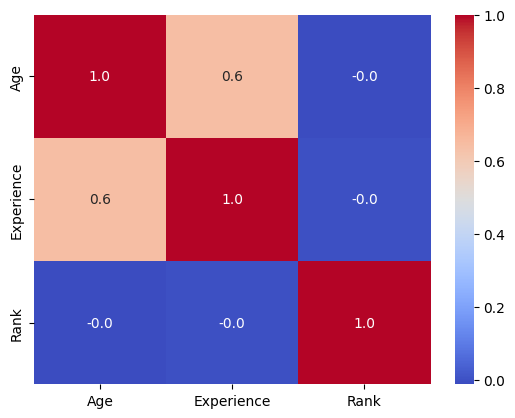

In [19]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='1.1f')

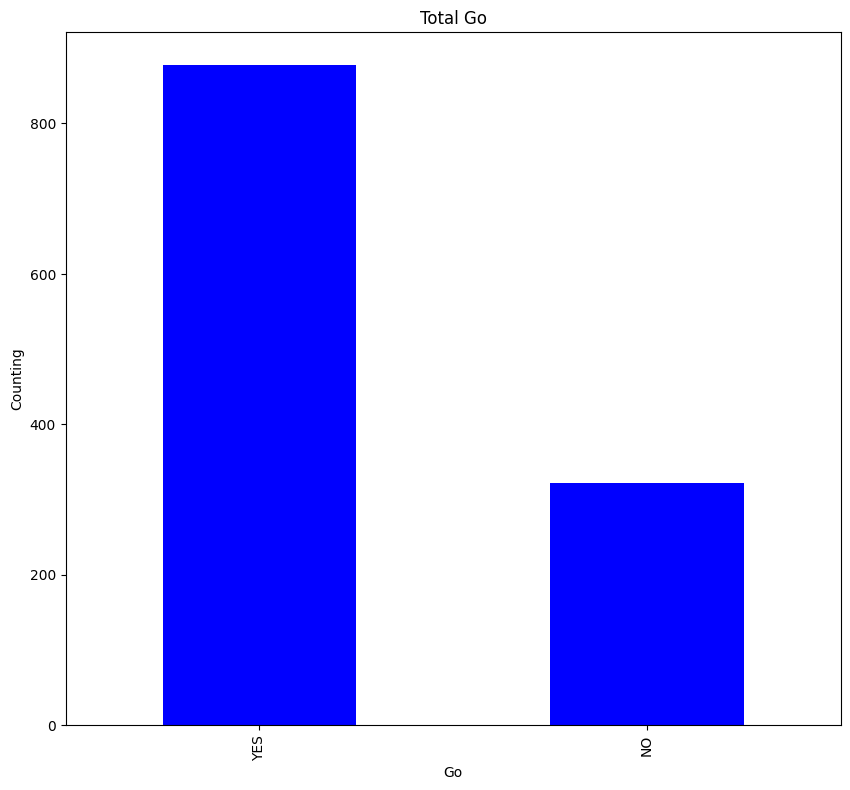

In [71]:
plt.figure(figsize=(10, 9))
df['Go'].value_counts().plot(kind='bar', color='blue')
plt.xlabel('Go')
plt.ylabel('Counting')
plt.title('Total Go')
plt.show()

In [72]:
from sklearn.preprocessing import LabelEncoder

In [73]:
encoder = LabelEncoder()

In [74]:
df['Nationality'] = encoder.fit_transform(df['Nationality'])
df['Go'] = encoder.fit_transform(df['Go'])

In [75]:
df.head()

,Age,Experience,Rank,Nationality,Go
0,58,7,1,1,0
1,26,1,9,7,1
2,20,0,2,4,0
3,56,1,9,4,1
4,62,34,7,4,1


In [76]:
df.tail()

,Age,Experience,Rank,Nationality,Go
1195,38,8,9,0,1
1196,57,36,8,2,1
1197,29,9,4,1,1
1198,18,0,1,2,0
1199,25,3,10,3,1


In [109]:
X = df[['Age','Experience','Rank','Nationality']]
y = df['Go']

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [110]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [111]:
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)

In [112]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [113]:
y_pred = dtc.predict(X_test)

In [132]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

In [120]:
acc = accuracy_score(y_test,y_pred)
print(f'the accuracy score is : {acc*100:.2f}%')

the accuracy score is : 89.58%


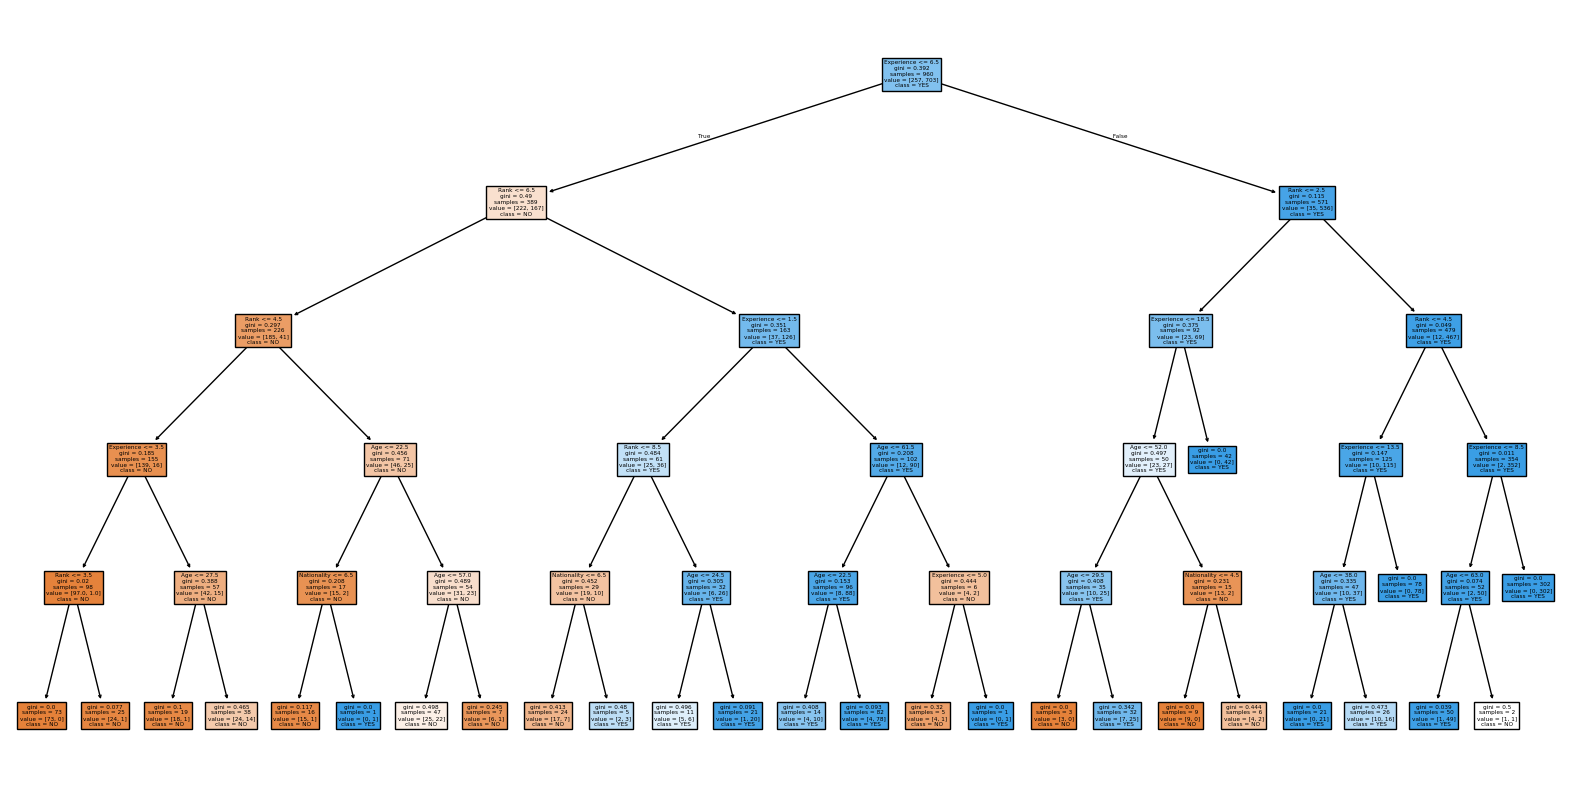

In [121]:
from sklearn import tree

features = X.columns
plt.figure(figsize=(20, 10))
tree.plot_tree(dtc, feature_names=features, filled=True, class_names=['NO', 'YES'])
plt.show()

In [129]:
f_score = f1_score(y_test,y_pred)
print(f'the f_score is: {f_score}')

the f_score is: 0.9287749287749287


In [127]:
metrics = confusion_matrix(y_test,y_pred)
print(f' {metrics}')

 [[ 52  13]
 [ 12 163]]


In [128]:
r_call_score = recall_score(y_test,y_pred)
print(r_call_score)

0.9314285714285714


In [133]:
report = classification_report(y_pred,y_test)
report

'              precision    recall  f1-score   support\n\n           0       0.80      0.81      0.81        64\n           1       0.93      0.93      0.93       176\n\n    accuracy                           0.90       240\n   macro avg       0.87      0.87      0.87       240\nweighted avg       0.90      0.90      0.90       240\n'